# Running k=7

Since the merge between the datasets created a lot of columns (over 2,000), it's necesary to reduce the dimensions of the dataset with PCA before running the k-means algorithm.

## Import Statements

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances_argmin_min, silhouette_samples

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
import folium

from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import ipywidgets as widgets
from ipywidgets import interact, interactive

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [2]:
X_ = np.load("scaled-df.npy")
df = pd.read_csv("bofedales-clean.csv")

The K-Means algorithm will run on the dataset in PC space.

## Find the Optimal Amount of Groups for K-Means

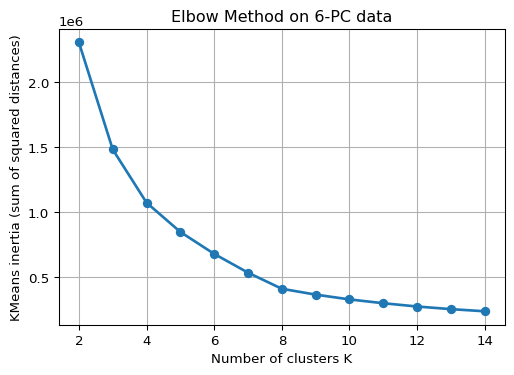

In [3]:
inertias = []
K_candidates = list(range(2, 15))

for k in K_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_candidates, inertias, marker='o', lw=2)
plt.xlabel("Number of clusters K")
plt.ylabel("KMeans inertia (sum of squared distances)")
plt.title("Elbow Method on 6-PC data")
plt.grid(True)
plt.show()

In [4]:
def kmeans_metrics(X, k_min=2, k_max=15, random_state=42):
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(X)

        rows.append(
            {
                "k": k,
                "silhouette": silhouette_score(X, labels),
                "davies_bouldin": davies_bouldin_score(X, labels),
                "calinski_harabasz": calinski_harabasz_score(X, labels),
            }
        )

    return pd.DataFrame(rows)


results = kmeans_metrics(X_, k_min=2, k_max=14)
print(results)

# Highlight the “best” K by each metric
best_k_sil = results.loc[results["silhouette"].idxmax(), "k"]
best_k_db  = results.loc[results["davies_bouldin"].idxmin(), "k"]
best_k_ch  = results.loc[results["calinski_harabasz"].idxmax(), "k"]

print(
    f"\nBest-by-metric suggestions:\n"
    f"  • Silhouette         ➜ K = {best_k_sil}\n"
    f"  • Davies-Bouldin (↓) ➜ K = {best_k_db}\n"
    f"  • Calinski-Harabasz  ➜ K = {best_k_ch}"
)

     k  silhouette  davies_bouldin  calinski_harabasz
0    2    0.704788        0.267676        2799.168737
1    3    0.490577        0.658183        3185.234991
2    4    0.451744        0.866056        3463.106294
3    5    0.462869        0.872874        3452.505330
4    6    0.487237        0.806739        3566.864417
5    7    0.480692        0.741089        3697.892571
6    8    0.545042        0.704286        4440.638367
7    9    0.548889        0.836006        4327.134360
8   10    0.561374        0.751318        4202.027964
9   11    0.555190        0.790261        4140.209356
10  12    0.549813        0.844028        4065.661088
11  13    0.500659        0.819958        4290.577527
12  14    0.496951        0.785910        4102.241704

Best-by-metric suggestions:
  • Silhouette         ➜ K = 2
  • Davies-Bouldin (↓) ➜ K = 2
  • Calinski-Harabasz  ➜ K = 8


From the graph, it looks like around 5-7 is the optional k value. Based on the indicators, k=2 is also an optimal value, but k=7 is also a good value.

This notebook will run k=7 in accordance with the Calinski-Harabasz metric and the elbow method. However, we will run k=2 in the following chapter. 

## Run K-Means with k=7

In [5]:
K=7
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_)
centroids_pca = kmeans.cluster_centers_ 
df["cluster"] = cluster_labels

In [6]:
cluster_means = df.groupby("cluster").mean().round(2)
cluster_means.drop("Unnamed: 0", axis=1, inplace=True)
cluster_means

,Area_m2,AUC,pct_prot,elev_mean_,elev_std_m,n_wells,1983_explr,1983_explt,1932_explt,Ground Water Rights 1966-01-01,...,NDWI 2019-03,NDWI 2019-04,NDWI 2019-05,NDWI 2019-06,NDWI 2019-07,NDWI 2019-08,NDWI 2019-09,NDWI 2019-10,NDWI 2019-11,NDWI 2019-12
cluster,,,,,,,,,,,,,,,,,,,,,
0,20100.00,102.58,18.44,4115.19,5.90,3778.00,5587.00,2789.00,711.00,80.0,...,0.06,0.06,0.05,0.04,0.03,0.01,0.01,0.03,0.04,0.04
1,59534.07,94.73,99.88,4398.82,6.09,0.00,129.00,43.00,20.00,0.0,...,0.04,0.03,0.01,-0.01,-0.02,-0.03,-0.03,-0.01,-0.01,0.00
2,21100.81,110.20,10.93,4226.67,8.19,57.13,222.66,1.00,0.02,0.0,...,0.07,0.06,0.05,0.02,0.01,-0.01,-0.02,-0.00,0.01,0.02
3,232978.72,101.47,50.32,4535.56,6.40,0.00,2.93,0.00,0.00,0.0,...,0.07,0.05,0.03,-0.00,-0.02,-0.03,-0.02,-0.01,0.01,0.02
4,43987.50,96.70,0.00,4216.39,4.37,0.00,164.25,0.00,0.00,0.0,...,0.08,0.08,0.06,0.04,0.03,0.02,0.01,0.04,0.07,0.09
5,58469.02,108.73,8.83,4187.01,6.91,0.00,91.96,13.81,5.53,0.0,...,0.10,0.09,0.08,0.06,0.06,0.04,0.04,0.05,0.07,0.08
6,74028.60,103.83,24.23,4266.85,7.55,0.00,144.65,15.28,1.26,0.0,...,0.09,0.08,0.07,0.05,0.04,0.03,0.03,0.04,0.04,0.07


In [7]:
print("Cluster counts:")
print(df["cluster"].value_counts().sort_index())

Cluster counts:
cluster
0    162
1    819
2    247
3    282
4     64
5    523
6    437
Name: count, dtype: int64


In [8]:
# Use the existing, saved dataset to prevent labels from shuffling
df = pd.read_csv("bofedales-clusters7.csv")
df.drop(["Unnamed: 0.1", "Unnamed: 0"], axis=1, inplace=True)

In [9]:
cluster_palette = {
    "GL":   "#693B11", # Brown
    "CPLN": "#F38D14", # Orange
    "PLSRV":"#9863D0", # Purple
    "PP":   "#C81A00", # Red
    "CPE":  "#3973ac", # Blue
    "PT":   "#339933", # Green
    "OC":   "#ff99dd", # Pink
}

df["cluster_name"] = df["cluster"].map({0: "Precordillera Tamarugal", 1: "Parque Lauca Sur y Reserva Las Vicuñas", 2: "Precordillera Putre", 3: "Caquena y Parque Lauca Norte", 4: "Ollagüe y Calama", 5: "Colchane y Pica Este", 6: "General Lagos"})

df["cluster_abr"] = df["cluster_name"].map({"Colchane y Pica Este": "CPE", "Caquena y Parque Lauca Norte": "CPLN", "Precordillera Tamarugal": "PT", "Precordillera Putre": "PP", "Parque Lauca Sur y Reserva Las Vicuñas": "PLSRV", "General Lagos": "GL", "Ollagüe y Calama": "OC"})

df["cluster_color"] = df["cluster_abr"].map(cluster_palette)

# Save the dataset
# df.to_csv("bofedales-clusters7.csv")
# (only for when running the first time) 

**List of Cluster Abbreviations**
- Cluster 0: Precordillera Tamarugal (PT)
- Cluster 1: Parque Lauca Sur y Reserva Las Vicuñas (PLSRV)
- Cluster 2: Precordillera Putre (PP)
- Cluster 3: Caquena y Parque Lauca Norte (CPLN)
- Cluster 4: Ollagüe y Calama (OC)
- Cluster 5: Colchane y Pica Este (CPE)
- Cluster 6: General Lagos (GL)

## Numerical Analysis

Overall, the clusters seem well-seperated

In [10]:
inertia = kmeans.inertia_
avg_sq_dist_per_sample = inertia / X_.shape[0]

print(f"Average squared distance per point: {avg_sq_dist_per_sample:.4f}")

Average squared distance per point: 211.4118


In [11]:
mu = X_.mean(axis=0)
global_mse = ((X_ - mu)**2).sum(axis=1).mean()
global_mse

np.float64(2162.723573987285)

Good reduction in MSE

### Silhouette Score
A measure of well each point sits in its own cluster vs the next best one
- s≈1 ⇒ the point is well matched to its own cluster and far from the next best cluster.
- s≈0 ⇒ the point sits right on the boundary between two clusters.
- s<0 ⇒ the point would be better placed in another cluster.

In [12]:
sil = silhouette_score(X_, kmeans.labels_)
print("Silhouette score:", sil)

Silhouette score: 0.5238542755606547


In [13]:
ch = calinski_harabasz_score(X_, kmeans.labels_)
print("Calinski–Harabasz index:", ch)

Calinski–Harabasz index: 3887.330140222049


In [14]:
db = davies_bouldin_score(X_, kmeans.labels_)
print("Davies–Bouldin index:", db)

Davies–Bouldin index: 0.7594967266956864


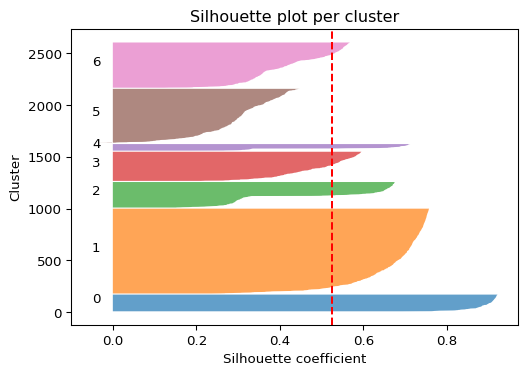

In [15]:
sil_vals = silhouette_samples(X_, cluster_labels)
y_lower = 10
plt.figure(figsize=(6,4))

for cid in np.unique(cluster_labels):
    c_sil = sil_vals[cluster_labels == cid]
    c_sil.sort()
    y_upper = y_lower + len(c_sil)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, c_sil, alpha=0.7)
    plt.text(-0.05, y_lower + len(c_sil)/2, str(cid))
    y_lower = y_upper + 10

plt.xlabel("Silhouette coefficient"); plt.ylabel("Cluster")
plt.axvline(sil_vals.mean(), color="red", linestyle="--")

plt.title("Silhouette plot per cluster")
plt.show()

## Feature Importance with Classification

In [16]:
t = DecisionTreeClassifier(max_depth=6, random_state=42)
feature_cols = [col for col in df.columns if col != "cluster_abr" and col != "cluster_name" and col != "cluster_color"]
t.fit(df[feature_cols], kmeans.labels_)
feat_imp = pd.Series(t.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_imp

Surface Water Rights 2013-01-01    0.333920
Precipitation 1988-05-01           0.211450
PET 1999-12-01                     0.176896
Temp Max 2013-11-01                0.121630
Precipitation 1995-10-01           0.090320
                                     ...   
Temp Max 1987-06-01                0.000000
Temp Max 1987-05-01                0.000000
Temp Max 1987-04-01                0.000000
Temp Max 1987-03-01                0.000000
cluster                            0.000000
Length: 2293, dtype: float64

Because of the way the data is formatted, interpret the above as general groups of variables/times instead of specific dates. One specific column or date might represent an overall trend. For example, surface water rights in 2018 is not as important as the overall trend.

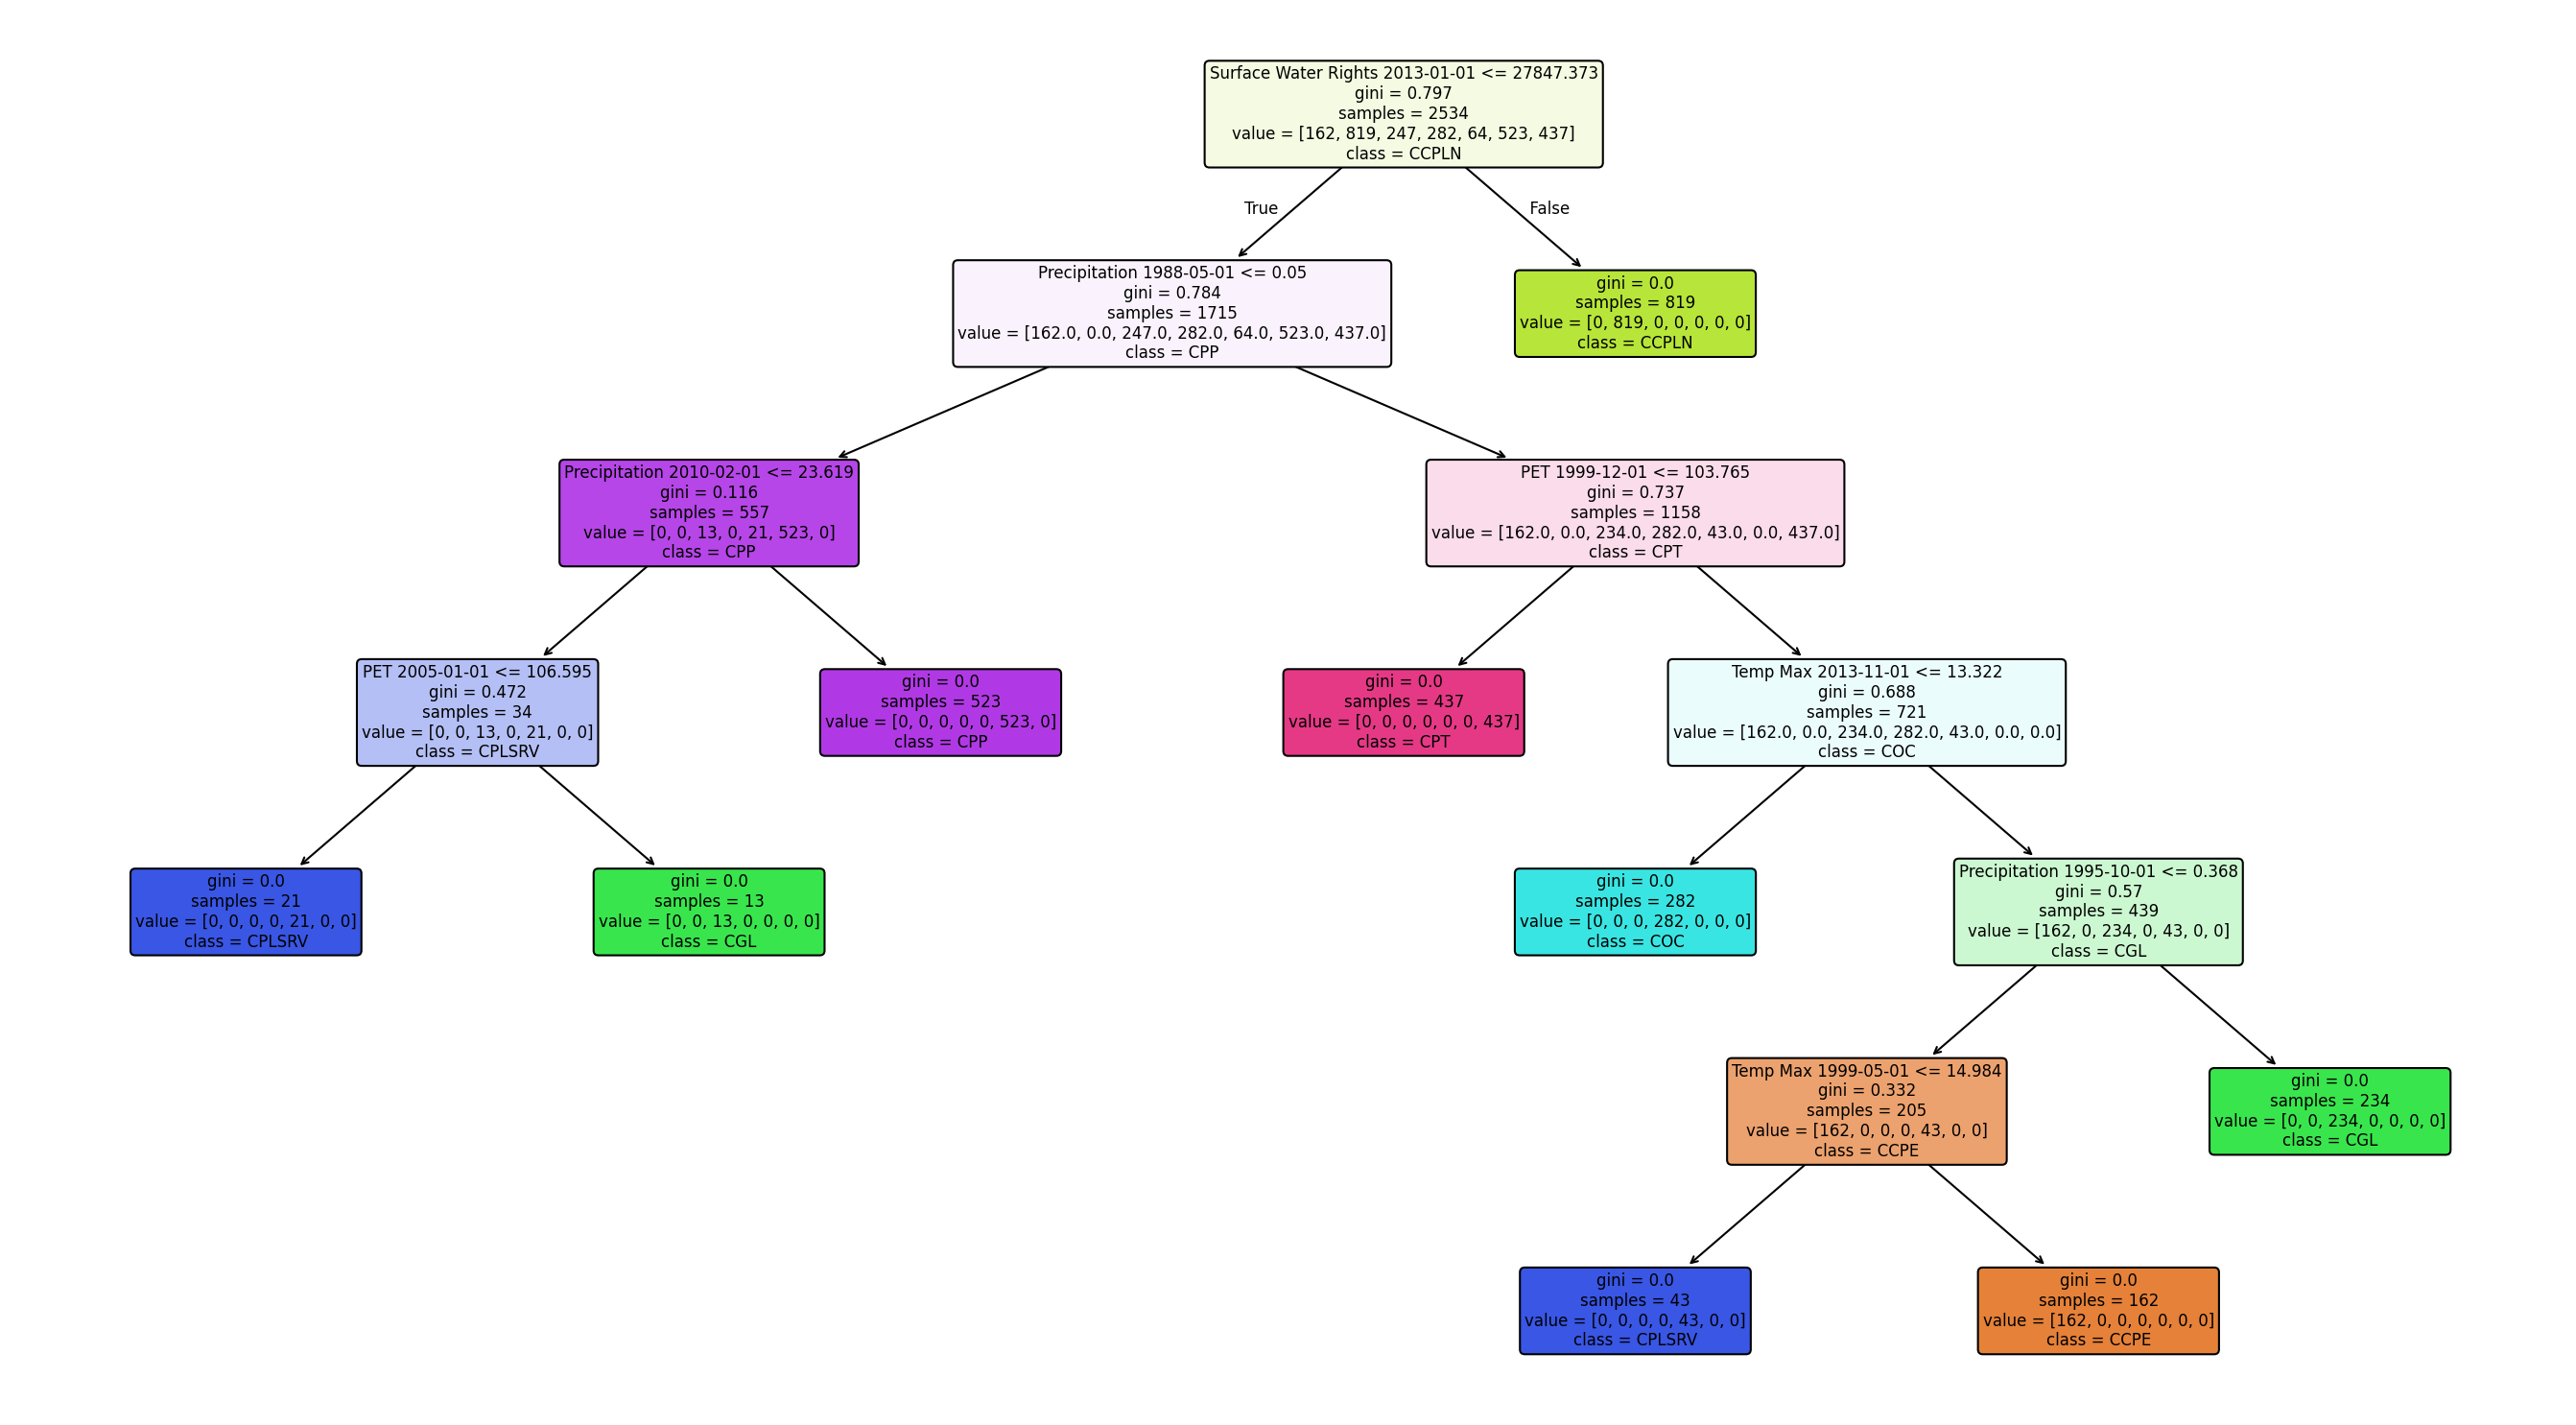

In [17]:
fig, ax = plt.subplots(figsize=(18, 10), dpi=150)
tree.plot_tree(
        t,
        feature_names=feature_cols,
        class_names=[f"C{i}" for i in sorted(set(df["cluster_abr"]))],
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax)
plt.tight_layout()
# gini is a purity measurement, where gini=0 means this leaf contains all bofedales belonging to the cluster

## Data Visualizations

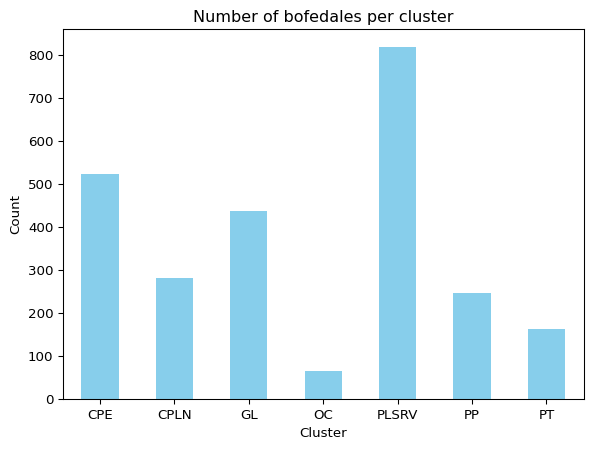

In [18]:
pd.Series(df["cluster_abr"]).value_counts().sort_index().plot.bar(color='skyblue')
plt.xlabel("Cluster"); plt.ylabel("Count")
plt.title("Number of bofedales per cluster")
plt.xticks(rotation=0)
plt.show()

In [19]:
geometry = [Point(xy) for xy in zip(df.lon, df.lat)]

gdf = gpd.GeoDataFrame(
    df.copy(), 
    geometry=geometry,
    crs="EPSG:4326"
)

gdf_4326 = gdf.to_crs(4326)
gdf_4326["size_for_plot"] = gdf["Area_m2"].apply(lambda a: (a**0.5))

gdf_4326["lon"] = gdf_4326.geometry.x
gdf_4326["lat"] = gdf_4326.geometry.y

tab10 = plt.colormaps.get_cmap("tab10")
cluster_ids = sorted(gdf_4326["cluster_abr"].unique())

cluster_colors = {
    cid: mcolors.to_hex(tab10(i % tab10.N))
    for i, cid in enumerate(cluster_ids)
}

center = [gdf_4326.lat.mean(), gdf_4326.lon.mean()]
m = folium.Map(center, zoom_start=6, tiles="OpenStreetMap")

sz = gdf_4326["size_for_plot"]
radii = np.interp(sz, (sz.min(), sz.max()), (2, 20))

for (_, row), radius in zip(gdf_4326.iterrows(), radii):
    folium.CircleMarker(
        location=(row.geometry.y, row.geometry.x),
        radius=radius,
        fill=True,
        fill_opacity=0.6,
        weight=0.3,
        color="black",
        fill_color=row.cluster_color,
        popup=(
            f"Cluster {row.cluster_abr}<br>"
            f"Area = {row.Area_m2:,} m²"
        ),
    ).add_to(m)
m

In [20]:
unit_mapping = {
    "Temp Min": "°C", 
    "Temp Max": "°C", 
    "Precipitation": "mm", 
    "Ground Water Rights": "L/s", 
    "Surface Water Rights": "L/s", 
    "PET": "mm", 
    "NDVI": "", 
    "NDWI": ""
}
vars_order = list(unit_mapping.keys())
default_var = vars_order[0]

# Optional guide lines
guide_lines = [
    # {"value": 0.0, "orientation": "h", "label": "Zero line", "color": "grey", "style": "dash", "width": 1},
]

long_parts = []
for var in vars_order:
    var_cols = [c for c in df.columns if c.startswith(f"{var} ")]
    if not var_cols:
        continue

    block = df[var_cols + ["cluster_abr"]].copy()
    date_index = pd.to_datetime(
        [c.replace(f"{var} ", "") for c in var_cols], errors="raise"
    )
    block.columns = date_index.tolist() + ["cluster_abr"]

    block = block.melt(id_vars="cluster_abr", var_name="date", value_name="value")
    block["variable"] = var
    block["date"] = pd.to_datetime(block["date"], errors="raise")

    long_parts.append(block)

tidy = pd.concat(long_parts, ignore_index=True)

tidy["year"] = tidy["date"].dt.year
tidy_annual = (
    tidy
      .groupby(["cluster_abr", "variable", "year"], as_index=False)
      .mean(numeric_only=True)
)

clusters = tidy_annual["cluster_abr"].unique()

fig = go.Figure()

for clus in clusters:
    sub = tidy_annual.query("cluster_abr == @clus and variable == @default_var")
    fig.add_trace(
        go.Scatter(
            x=sub["year"],
            y=sub["value"],
            mode="lines",
            name=clus,
            line=dict(color=cluster_palette[clus], width=2)
        )
    )

for ln in guide_lines:
    if ln["orientation"].lower().startswith("h"):
        fig.add_shape(
            type="line",
            x0=tidy_annual["year"].min(), x1=tidy_annual["year"].max(),
            y0=ln["value"], y1=ln["value"],
            line=dict(color=ln.get("color", "red"),
                      dash=ln.get("style", "dash"),
                      width=ln.get("width", 2))
        )
    else:
        fig.add_shape(
            type="line",
            y0=tidy_annual["value"].min(), y1=tidy_annual["value"].max(),
            x0=ln["value"], x1=ln["value"],
            line=dict(color=ln.get("color", "red"),
                      dash=ln.get("style", "dash"),
                      width=ln.get("width", 2))
        )

buttons = []
for var in vars_order:
    ys = [
        tidy_annual.query("cluster_abr == @clus and variable == @var")["value"].values
        for clus in clusters
    ]
    label = var + (f" ({unit_mapping[var]})" if unit_mapping[var] else "")
    buttons.append(
        dict(
            label  = var,
            method = "update",
            args   = [
                {"y": ys},
                {
                  "title": f"Average {var} by Cluster",
                  "yaxis": {"title": {"text": label}}
                }
            ]
        )
    )

fig.update_layout(
    xaxis_title="Year",
    yaxis_title=f"{default_var}" + (f" ({unit_mapping[default_var]})" if unit_mapping[default_var] else ""),
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        buttons=buttons,
        x=0.0, xanchor="left",
        y=1.15, yanchor="top"
    )],
    legend_title_text="Cluster",
    height=500, width=900,
    margin=dict(t=90, r=20, l=60, b=50)
)

fig

In [21]:
df_condensed = (
    df[['Area_m2', 'AUC', 'pct_prot', 'elev_mean_', 'elev_std_m',
        'n_wells', 'cluster_abr', '1983_explr', '1983_explt', '1932_explt']]
      .rename(columns={
          'pct_prot': 'Percentage Protected Land (of total bofedal)',
          'Area_m2' : 'Area (in m²)',
          'AUC'     : 'Area of basin',
          'elev_mean_': 'Average Elevation (in m)',
          'elev_std_m': 'Elevation Standard Deviation (in m)',
          'n_wells'   : 'Number of wells (per catchment area)',
          '1983_explr': 'Mining Exploration Sites in 1983',
          '1983_explt': 'Mining Exploitation Sites in 1983',
          '1932_explt': 'Mining Exploitation Sites in 1932'
      })
)

agg = (df_condensed
       .groupby("cluster_abr", as_index=False)
       .mean())
bar_colors = agg["cluster_abr"].map(cluster_palette).fillna("#999999").tolist()

def make_trace(var):
    return go.Bar(
        x=agg["cluster_abr"],
        y=agg[var],
        marker=dict(color=bar_colors, line=dict(color="black")),
        name=var
    )

vars_list   = list(agg.columns[1:])
default_var = vars_list[0]

fig = go.Figure(make_trace(default_var))

buttons = []
for i, var in enumerate(vars_list):
    buttons.append(
        dict(
            label  = var,
            method = "update",
            args   = [
                {"y": [agg[var]]},
                 # "marker.color": [palette[i % len(palette)]]},
                {
                  "yaxis": {"title": {"text": var}}
                }
            ]
        )
    )

fig.update_layout(
    title="",
    yaxis=dict(title=dict(text=default_var)),
    xaxis=dict(
        title="Cluster",
        type="category",
        categoryorder="array",
        categoryarray=agg["cluster_abr"].tolist()
    ),
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        showactive=True,
        buttons=buttons,
        x=0.0, xanchor="left",
        y=1.15, yanchor="top"
    )],
    margin=dict(t=60, r=20, l=60, b=50),
    height=450, width=700,
    showlegend=False
)


fig